<a href="https://colab.research.google.com/github/HafidzKurniawan/Assignment-ComputerVisionImageAnalyst/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving hitam2.jpg to hitam2 (1).jpg


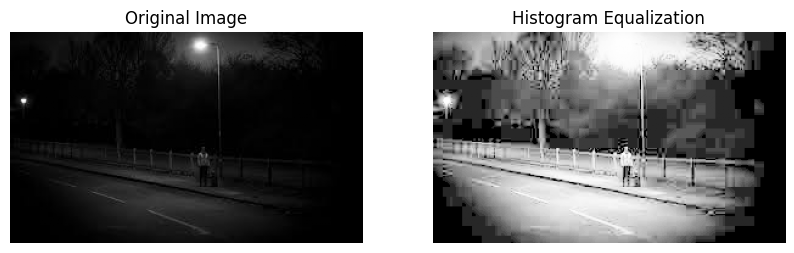

In [18]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Upload file dari komputer
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]

# Load image
img = Image.open(filename).convert("L")
img_array = np.array(img)

# Hitung histogram
histogram = np.zeros(256)

for pixel in img_array.flatten():
    histogram[pixel] += 1

# Hitung PDF
num_pixels = img_array.size
pdf = histogram / num_pixels

# Hitung CDF
cdf = np.cumsum(pdf)

# Mapping intensitas baru
L = 256
transform_map = np.floor((L - 1) * cdf).astype(np.uint8)

# Apply transform ke image
equalized_img = transform_map[img_array]

# Tampilkan hasil
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_array, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Histogram Equalization")
plt.imshow(equalized_img, cmap="gray")
plt.axis("off")

plt.show()

Saving Cuplikan layar 2026-03-09 224327.png to Cuplikan layar 2026-03-09 224327 (4).png


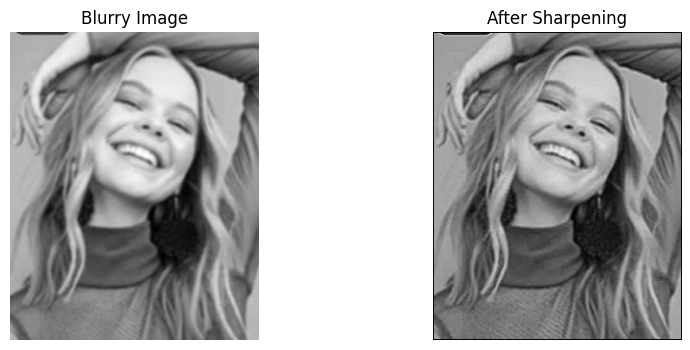

In [27]:
#Image Sharpening

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# load image grayscale
img = Image.open(filename).convert("L")
image = np.array(img)

# menentukan kernel

kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# sharpening image
sharpened = np.zeros_like(image)

for i in range(1, rows-1):
    for j in range(1, cols-1):

        region = image[i-1:i+2, j-1:j+2]

        value = np.sum(region * kernel)

        sharpened[i, j] = np.clip(value, 0, 255)

# menampilkan hasil sharpening

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Blurry Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sharpened, cmap="gray")
plt.title("After Sharpening")
plt.axis("off")

plt.show()

Saving contrast2.jpg to contrast2 (2).jpg


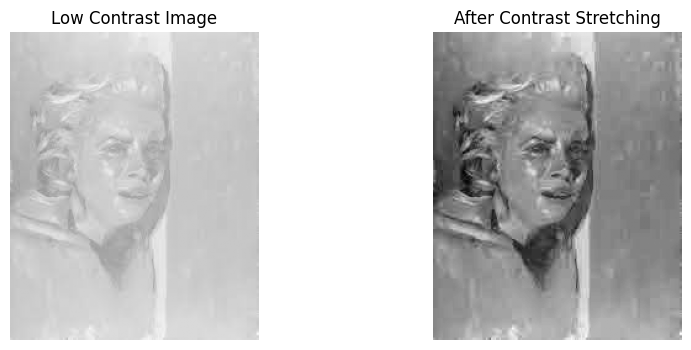

In [23]:
#Contrast Stretching

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load image grayscale
img = Image.open(filename).convert("L")
image = np.array(img)

r_min = image.min()
r_max = image.max()

# contrast stretching
stretched = np.zeros_like(image)

for i in range(rows):
    for j in range(cols):

        r = image[i,j]

        s = (r - r_min) / (r_max - r_min) * 255

        stretched[i,j] = np.clip(s,0,255)

# menampilkan hasil stretching
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Low Contrast Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(stretched, cmap="gray", vmin=0, vmax=255)
plt.title("After Contrast Stretching")
plt.axis("off")

plt.show()